# Task 4: PCA and K-Means (20 points)

## 4(a) Features/Labels Split and Standardization
Split the data into features and labels, then apply z-score standardization using `StandardScaler`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

# 1. Load data
df = pd.read_csv('mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range']

# 2. Standardize using z-score (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Standardization complete. Feature matrix shape: {X_scaled.shape}")

Standardization complete. Feature matrix shape: (2000, 20)


## 4(b) PCA Projection (2D Visualization)
Project the features onto 2 dimensions using PCA and visualize the scatter plot with class labels.

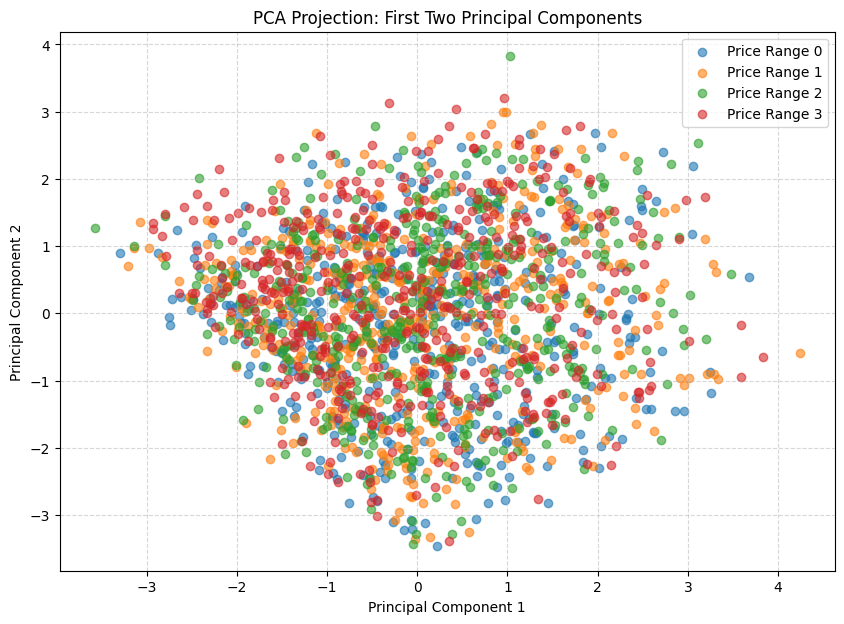

In [2]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for label in sorted(y.unique()):
    mask = (y == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Price Range {label}', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection: First Two Principal Components')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4(c) K-Means Clustering on All Features
Apply K-Means to cluster the data into 4 clusters using all features. Visualize and report Adjusted Rand Score.

Adjusted Rand Score (All Features): 0.0060


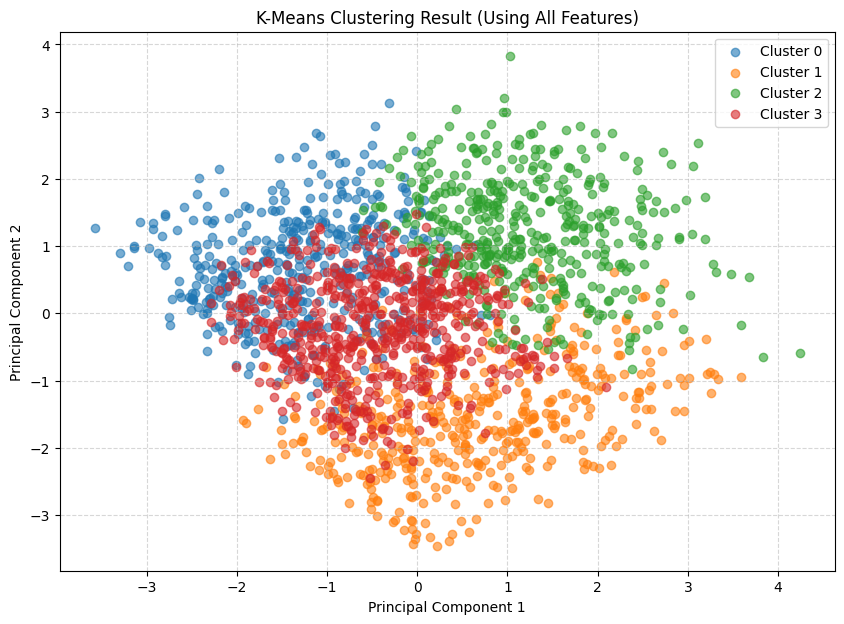

In [3]:
kmeans_all = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_all = kmeans_all.fit_predict(X_scaled)

ars_all = adjusted_rand_score(y, labels_all)
print(f"Adjusted Rand Score (All Features): {ars_all:.4f}")

# Visualization using PCA components
plt.figure(figsize=(10, 7))
for cluster in sorted(np.unique(labels_all)):
    mask = (labels_all == cluster)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}', alpha=0.6)

plt.title('K-Means Clustering Result (Using All Features)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4(d) K-Means Clustering on 2D PCA Features
Apply K-Means to cluster the samples into 4 clusters using the 2D features from PCA.

Adjusted Rand Score (PCA 2D Features): 0.0017


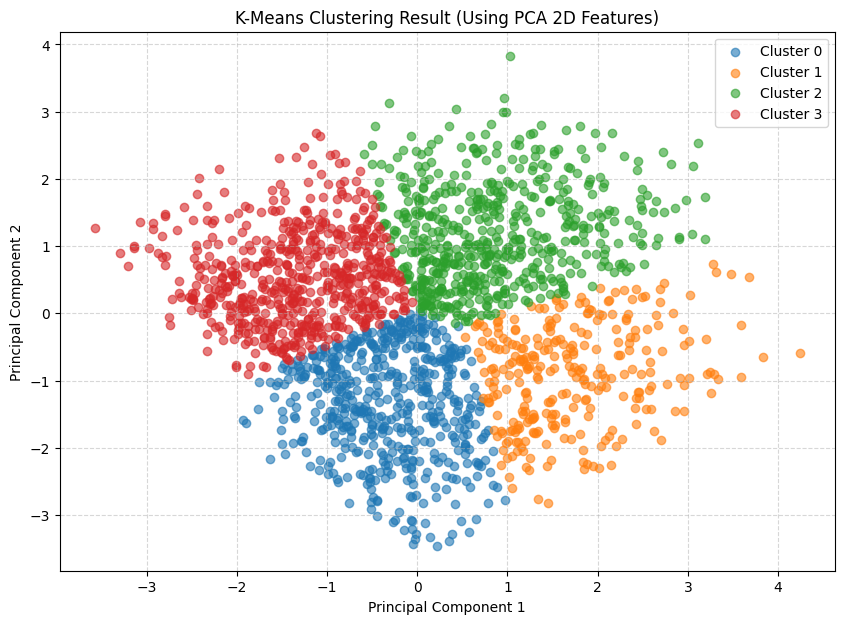

In [4]:
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

ars_pca = adjusted_rand_score(y, labels_pca)
print(f"Adjusted Rand Score (PCA 2D Features): {ars_pca:.4f}")

plt.figure(figsize=(10, 7))
for cluster in sorted(np.unique(labels_pca)):
    mask = (labels_pca == cluster)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}', alpha=0.6)

plt.title('K-Means Clustering Result (Using PCA 2D Features)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4(e) Observations
Compare the performance between 4(c) and 4(d) and describe your findings.